In [1]:
import sys
sys.path.append("/Users/emilieyu/endotehelial-masboss")

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import copy

from abm.rho_lookup_table import RhoLookupTable
from abm.endothelial_cell import EndothelialCell
from abm.stress_fibre import StressFibre
from abm.flow_field import FlowField
from src.config import load_abm_sim_cfg, load_bm_sweep_cfg
from src.paths import BM_RESULTS_DIR

from abm.scripts.run_abm_sim import run_abm_sim, run_abm_sim_single, get_perb_cfg, plot_cell

sim_cfg = load_abm_sim_cfg()
lut = RhoLookupTable(sim_cfg, BM_RESULTS_DIR)
perbs = sim_cfg['perturbations']


>>> DEBUG: Successfully loaded recruitment parameter sweep data.
>>> DEBUG: Successfully built interpolators
LUT ready | rest: RhoA=0.395 RhoC=0.406


In [2]:
dsp_cfg = get_perb_cfg(sim_cfg, perbs['DSP_KO'])
tjp1_cfg = get_perb_cfg(sim_cfg, perbs['TJP1_KO'])
jcad_cfg = get_perb_cfg(sim_cfg, perbs['JCAD_KO'])
tjp1_jcad_cfg = get_perb_cfg(sim_cfg, perbs['TJP1_JCAD_DKO'])
dsp_jcad_cfg = get_perb_cfg(sim_cfg, perbs['DSP_JCAD_DKO'])

{'length': 41.200553966250325, 'rest_length': 26.29068276024797, 'unit_vec': array([ 1.00000000e+00, -3.88959305e-17]), 'tension': 2.421987814863476, 'force_vector': array([ 2.42198781e+00, -9.42054698e-17]), 'contractility': 0.27073544559262636}


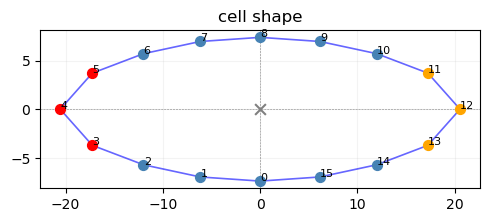

In [3]:
res_jcad = run_abm_sim_single(jcad_cfg, lut, 6000, 'JCAD', True)

In [5]:
res_jcad['cell_final'], res_jcad['springs_final']

({'cell_id': 0,
  'ar': np.float64(2.113),
  'orientation': np.float64(0.0),
  'area_ratio': np.float64(0.9919),
  'pole_mean_rhoa': 0.466,
  'lat_mean_rhoa': 0.311,
  'mean_rhoc': 0.568,
  'a_sf': 0.268,
  'sf_tension': 2.325,
  'a_cortex_pole': 1.0},
     id   side       L      L0  stiffness  tension  alignment
 0    0  flank  5.6833  4.6822     2.0411   2.0436      0.997
 1    1  flank  5.5801  4.6822     2.4225   2.1770      0.974
 2    2  polar  5.3994  4.6822     3.3993   2.4406      0.924
 3    3  polar  5.0782  4.6822     4.2667   1.6905      0.619
 4    4  polar  5.0782  4.6822     4.2667   1.6905      0.619
 5    5  polar  5.3994  4.6822     3.3993   2.4406      0.924
 6    6  flank  5.5801  4.6822     2.4225   2.1770      0.974
 7    7  flank  5.6833  4.6822     2.0411   2.0436      0.997
 8    8  flank  5.6833  4.6822     2.0411   2.0436      0.997
 9    9  flank  5.5801  4.6822     2.4225   2.1770      0.974
 10  10  polar  5.3994  4.6822     3.3993   2.4406      0.924
 11

{'length': 40.27805413316125, 'rest_length': 26.29068276024797, 'unit_vec': array([ 1.00000000e+00, -7.35736979e-17]), 'tension': 2.7144930297449896, 'force_vector': array([ 2.71449303e+00, -1.99715290e-16]), 'contractility': 0.3234469166995925}


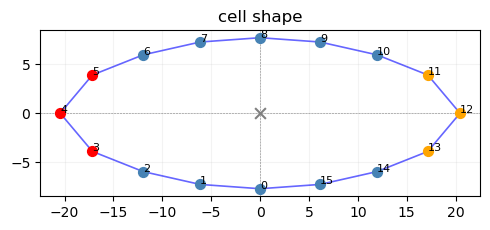

In [4]:
res_wt = run_abm_sim_single(sim_cfg, lut, 6000, 'WT', True)

In [7]:
res_wt['cell_final'], res_wt['springs_final']

({'cell_id': 0,
  'ar': np.float64(2.057),
  'orientation': np.float64(0.0),
  'area_ratio': np.float64(1.0014),
  'pole_mean_rhoa': 0.537,
  'lat_mean_rhoa': 0.316,
  'mean_rhoc': 0.622,
  'a_sf': 0.322,
  'sf_tension': 2.705,
  'a_cortex_pole': 1.0},
     id   side       L      L0  stiffness  tension  alignment
 0    0  flank  5.6896  4.6822     2.0152   2.0303      0.997
 1    1  flank  5.5628  4.6822     2.4848   2.1894      0.972
 2    2  polar  5.3350  4.6822     3.8782   2.5338      0.918
 3    3  polar  5.0564  4.6822     5.1481   1.9270      0.599
 4    4  polar  5.0564  4.6822     5.1481   1.9270      0.599
 5    5  polar  5.3350  4.6822     3.8782   2.5338      0.918
 6    6  flank  5.5628  4.6822     2.4848   2.1894      0.972
 7    7  flank  5.6896  4.6822     2.0152   2.0303      0.997
 8    8  flank  5.6896  4.6822     2.0152   2.0303      0.997
 9    9  flank  5.5628  4.6822     2.4848   2.1894      0.972
 10  10  polar  5.3350  4.6822     3.8782   2.5338      0.918
 11

{'length': 43.0505027359106, 'rest_length': 26.29068276024797, 'unit_vec': array([1.00000000e+00, 2.08865712e-16]), 'tension': 3.7348093960020403, 'force_vector': array([3.73480940e+00, 7.80073624e-16]), 'contractility': 0.3714044338974074}


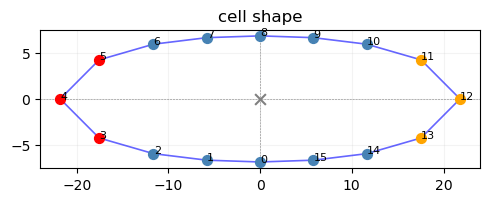

In [5]:
res_dsp = run_abm_sim_single(dsp_cfg, lut, 6000, 'WT', True)

In [9]:
res_dsp['cell_final'], res_dsp['springs_final']

({'cell_id': 0,
  'ar': np.float64(2.204),
  'orientation': np.float64(180.0),
  'area_ratio': np.float64(1.0782),
  'pole_mean_rhoa': 0.217,
  'lat_mean_rhoa': 0.278,
  'mean_rhoc': 0.67,
  'a_sf': 0.37,
  'sf_tension': 3.999,
  'a_cortex_pole': 1.0},
     id   side       L      L0  stiffness  tension  alignment
 0    0  flank  5.3178  4.6822     1.9933   1.2669      1.000
 1    1  flank  5.5124  4.6822     1.9267   1.5998      0.995
 2    2  polar  6.0828  4.6822     1.5369   2.1525      0.964
 3    3  polar  6.1404  4.6822     1.1966   1.7446      0.708
 4    4  polar  6.1404  4.6822     1.1966   1.7446      0.708
 5    5  polar  6.0828  4.6822     1.5369   2.1525      0.964
 6    6  flank  5.5124  4.6822     1.9267   1.5998      0.995
 7    7  flank  5.3178  4.6822     1.9933   1.2669      1.000
 8    8  flank  5.3178  4.6822     1.9933   1.2669      1.000
 9    9  flank  5.5124  4.6822     1.9267   1.5998      0.995
 10  10  polar  6.0828  4.6822     1.5369   2.1525      0.964
 11

{'length': 40.77479005682436, 'rest_length': 24.0, 'unit_vec': array([1.0000000e+00, 9.2390737e-16]), 'tension': 3.21111245638752, 'force_vector': array([3.21111246e+00, 2.96677047e-15]), 'contractility': 0.31904149475462673}


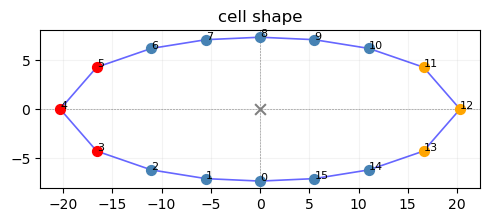

In [10]:
res_dsp_jcad = run_abm_sim_single(dsp_jcad_cfg, lut, 6000, 'DSP_JCAD', True)

In [9]:
res_dsp_jcad['cell_final'], res_dsp_jcad['springs_final']

({'cell_id': 0,
  'ar': np.float64(2.203),
  'orientation': np.float64(180.0),
  'area_ratio': np.float64(0.9958),
  'pole_mean_rhoa': 0.283,
  'lat_mean_rhoa': 0.283,
  'mean_rhoc': 0.619,
  'a_sf': 0.319,
  'sf_tension': 3.633,
  'a_cortex_pole': 1.0},
     id   side       L      L0  stiffness  tension  alignment
 0    0  flank  5.4441  4.6822     1.9947   1.5199      0.999
 1    1  flank  5.5851  4.6822     1.9947   1.8011      0.988
 2    2  polar  5.8425  4.6822     1.9947   2.3145      0.946
 3    3  polar  5.5978  4.6822     1.9947   1.8265      0.652
 4    4  polar  5.5978  4.6822     1.9947   1.8265      0.652
 5    5  polar  5.8425  4.6822     1.9947   2.3145      0.946
 6    6  flank  5.5851  4.6822     1.9947   1.8011      0.988
 7    7  flank  5.4441  4.6822     1.9947   1.5199      0.999
 8    8  flank  5.4441  4.6822     1.9947   1.5199      0.999
 9    9  flank  5.5851  4.6822     1.9947   1.8011      0.988
 10  10  polar  5.8425  4.6822     1.9947   2.3145      0.946
 

{'length': 40.91623769827067, 'rest_length': 26.29068276024797, 'unit_vec': array([1.00000000e+00, 5.35790297e-17]), 'tension': 0.2124627155463162, 'force_vector': array([2.12462716e-01, 1.13835462e-17]), 'contractility': 0.024211627830318497}


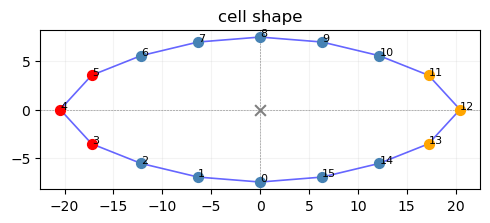

In [6]:
res_tjp1 = run_abm_sim_single(tjp1_cfg, lut, 6000, 'TJP1', True)

In [11]:
res_tjp1['cell_final'], res_tjp1['springs_final']

({'cell_id': 0,
  'ar': np.float64(1.97),
  'orientation': np.float64(0.0),
  'area_ratio': np.float64(1.0003),
  'pole_mean_rhoa': 0.673,
  'lat_mean_rhoa': 0.424,
  'mean_rhoc': 0.337,
  'a_sf': 0.037,
  'sf_tension': 0.34,
  'a_cortex_pole': 1.0},
     id   side       L      L0  stiffness  tension  alignment
 0    0  flank  5.5634  4.6822     3.3818   2.9802      0.996
 1    1  flank  5.4747  4.6822     3.7748   2.9915      0.966
 2    2  polar  5.2645  4.6822     5.2378   3.0500      0.909
 3    3  polar  4.9889  4.6822     6.8349   2.0967      0.591
 4    4  polar  4.9889  4.6822     6.8349   2.0967      0.591
 5    5  polar  5.2645  4.6822     5.2378   3.0500      0.909
 6    6  flank  5.4747  4.6822     3.7748   2.9915      0.966
 7    7  flank  5.5634  4.6822     3.3818   2.9802      0.996
 8    8  flank  5.5634  4.6822     3.3818   2.9802      0.996
 9    9  flank  5.4747  4.6822     3.7748   2.9915      0.966
 10  10  polar  5.2645  4.6822     5.2378   3.0500      0.909
 11  

{'length': 37.2644139569792, 'rest_length': 24.0, 'unit_vec': array([1.000000e+00, 4.503747e-17]), 'tension': 0.5748149743959505, 'force_vector': array([5.74814974e-01, 2.58882122e-17]), 'contractility': 0.0722254187523708}


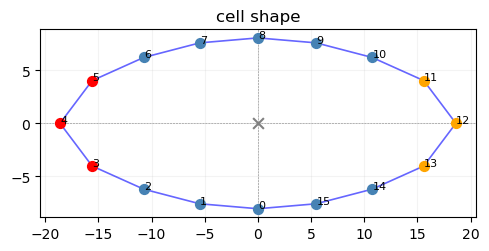

In [14]:
res_tjp1_jcad = run_abm_sim_single(tjp1_jcad_cfg, lut, 6000, 'TJP1_JCAD', True)

In [16]:
res_tjp1_jcad['cell_final'], res_tjp1_jcad['springs_final']

({'cell_id': 0,
  'ar': np.float64(1.976),
  'orientation': np.float64(0.0),
  'area_ratio': np.float64(0.9965),
  'pole_mean_rhoa': 0.556,
  'lat_mean_rhoa': 0.414,
  'mean_rhoc': 0.366,
  'a_sf': 0.072,
  'sf_tension': 0.575,
  'a_cortex_pole': 1.0},
     id   side       L      L0  stiffness  tension  alignment
 0    0  flank  5.4978  4.6822     3.3771   2.7544      0.996
 1    1  flank  5.4527  4.6822     3.6311   2.7979      0.968
 2    2  polar  5.3271  4.6822     4.4532   2.8721      0.912
 3    3  polar  5.0331  4.6822     5.3784   1.8875      0.600
 4    4  polar  5.0331  4.6822     5.3784   1.8875      0.600
 5    5  polar  5.3271  4.6822     4.4532   2.8721      0.912
 6    6  flank  5.4527  4.6822     3.6311   2.7979      0.968
 7    7  flank  5.4978  4.6822     3.3771   2.7544      0.996
 8    8  flank  5.4978  4.6822     3.3771   2.7544      0.996
 9    9  flank  5.4527  4.6822     3.6311   2.7979      0.968
 10  10  polar  5.3271  4.6822     4.4532   2.8721      0.912
 11

In [3]:

ts_df, ss_df, diag_ts_df, diag_ss_df = run_abm_sim(sim_cfg, lut, 6000)

>>> INFO: Running abm simulation perturbation: WT (6000 steps).
{'length': 38.103273623876845, 'rest_length': 26.29068276024797, 'unit_vec': array([ 1.00000000e+00, -1.13736754e-16]), 'tension': 2.6589157590740276, 'force_vector': array([ 2.65891576e+00, -3.02416447e-16]), 'contractility': 0.3215596287072607}
WT                  2.160    180.0°  0.322 
>>> INFO: Running abm simulation perturbation: DSP_KO (6000 steps).
{'length': 42.88072718034188, 'rest_length': 26.29068276024797, 'unit_vec': array([1.00000000e+00, 2.55826922e-15]), 'tension': 4.329483273649207, 'force_vector': array([4.32948327e+00, 1.10759838e-14]), 'contractility': 0.37281254041378686}
DSP_KO              2.275   -180.0°  0.373 
>>> INFO: Running abm simulation perturbation: TJP1_KO (6000 steps).
{'length': 37.91139150213095, 'rest_length': 26.29068276024797, 'unit_vec': array([1.00000000e+00, 3.23924034e-17]), 'tension': 0.12693117969351214, 'force_vector': array([1.26931180e-01, 4.11160597e-18]), 'contractility':

In [3]:
ss_df

,perturbation,cell_id,ar,orientation,area_ratio,pole_mean_rhoa,lat_mean_rhoa,mean_rhoc,a_sf,sf_tension,a_cortex_pole
0,WT,0,2.040,180.0,1.0167,0.536,0.315,0.622,0.322,2.678,1.0
1,DSP_KO,0,2.297,180.0,1.0080,0.217,0.278,0.670,0.370,4.091,1.0
2,TJP1_KO,0,1.924,-180.0,1.0115,0.720,0.464,0.316,0.015,0.118,1.0
3,JCAD_KO,0,2.081,0.0,1.0162,0.467,0.312,0.567,0.267,2.361,1.0
4,DSP_JCAD_DKO,0,2.179,180.0,1.0318,0.283,0.283,0.619,0.319,3.221,1.0
5,TJP1_JCAD_DKO,0,1.968,-180.0,0.9980,0.587,0.436,0.352,0.052,0.408,1.0


In [15]:
diag_ss_df

,perturbation,shear_fn_pole,shear_fn_lat,shear_fn_diff,shear_tangential,cortex_T_pole,cortex_T_lat,a_cortex_pole,a_cortex_lat,sf_tension,sf_node_max,a_sf,area_pressure
0,WT,11.006,7.542,3.464,17.096,3.337,4.399,1.0,1.0,3.467,1.7335,0.0,2.7849
1,DSP_KO,10.386,0.634,9.752,17.290,3.088,2.749,1.0,1.0,3.702,1.8510,0.0,0.0000
2,TJP1_KO,13.835,3.126,10.709,16.517,2.028,3.175,1.0,1.0,0.000,0.0000,0.0,0.4720
3,JCAD_KO,10.756,4.053,6.703,17.784,2.523,2.931,1.0,1.0,2.201,1.1005,0.0,0.0000
4,DSP_JCAD_DKO,10.679,0.783,9.896,17.251,2.740,2.742,1.0,1.0,2.709,1.3545,0.0,0.0000
5,TJP1_JCAD_DKO,13.409,2.922,10.487,16.642,1.939,3.005,1.0,1.0,0.000,0.0000,0.0,0.2948
